#REVERT THE CHANGES TO MAKE IT PREDICT ABL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from datetime import timedelta
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import gc
tf.keras.backend.clear_session()
gc.collect()
CONFIG = {
    'short': 12,
    'mid': 24,
    'long': 48,

    'batch_size': 16,
    'epochs': 30,

    'gcn_dim': 16,
    'tcn_dim': 32,
    'hidden_dim': 64,
    'embed_dim': 4,

    'train_ratio': 0.7,
    'val_ratio': 0.15
}

In [ ]:
def normalize_adj(A):
    import numpy as np

    # Add self-loops
    A = A + np.eye(A.shape[0])

    # Degree matrix
    D = np.sum(A, axis=1)

    # D^(-1/2)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-8))

    # Symmetric normalization
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    return A_norm

In [ ]:
class DataLoaderTF:
    def __init__(self, data_path, adj_path):
        self.data_path = data_path
        self.adj_path  = adj_path

    def load(self):
        import numpy as np

        # ============================================================
        # Load data
        # ============================================================
        data = np.load(self.data_path)   # (T, N)
        adj  = np.load(self.adj_path)    # (N, N)
        adj = normalize_adj(adj)
        print("Data shape:", data.shape)
        print("Adj shape :", adj.shape)

        T, N = data.shape

        # ============================================================
        # Base feature: speed
        # ============================================================
        speed = np.expand_dims(data, -1)   # (T, N, 1)

        # ============================================================
        # Time-of-day features (VERY IMPORTANT)
        # ============================================================
        time_idx = np.arange(T)

        # 5-min intervals → 288 steps per day
        time_sin = np.sin(2 * np.pi * time_idx / 288)
        time_cos = np.cos(2 * np.pi * time_idx / 288)

        time_feats = np.stack([time_sin, time_cos], axis=1)   # (T, 2)
        time_feats = np.repeat(time_feats[:, None, :], N, axis=1)  # (T, N, 2)

        # ============================================================
        # Day-of-week features (adds extra signal)
        # ============================================================
        dow = (time_idx // 288) % 7

        dow_sin = np.sin(2 * np.pi * dow / 7)
        dow_cos = np.cos(2 * np.pi * dow / 7)

        dow_feats = np.stack([dow_sin, dow_cos], axis=1)  # (T, 2)
        dow_feats = np.repeat(dow_feats[:, None, :], N, axis=1)  # (T, N, 2)
        lag_1   = np.roll(data, 1, axis=0)
        lag_6   = np.roll(data, 6, axis=0)
        lag_144 = np.roll(data, 144, axis=0)

        # fix invalid rolled values
        lag_1[:1] = 0
        lag_6[:6] = 0
        lag_144[:144] = 0

        lag_1   = np.expand_dims(lag_1, -1)
        lag_6   = np.expand_dims(lag_6, -1)
        lag_144 = np.expand_dims(lag_144, -1)
        # ============================================================
        # Combine ALL features
        # ============================================================
        X = np.concatenate([
          speed,
          lag_1,
          lag_6,
          lag_144,
          time_feats,
          dow_feats
          ], axis=-1)
        # Final shape: (T, N, 5)

        # Target = predict speed

        prev_speed = speed[:-1]
        curr_speed = speed[1:]

        # relative delta
        Y = (curr_speed - prev_speed) / (prev_speed + 1e-5)

        # clip unrealistic jumps
        Y = np.clip(Y, -1.0, 1.0)

        # align X
        X = X[1:]

        print("Relative delta min/max:",Y.min(),Y.max())

        # Dummy node IDs
        cells = list(range(N))

        return X.astype(np.float32), Y.astype(np.float32), cells, adj

In [ ]:
def make_dataset(X, Y, indices, shuffle=False):

    short = CONFIG['short']
    mid   = CONFIG['mid']
    long_len  = CONFIG['long']

    def gen():
        idx = np.array(indices)
        if shuffle:
            np.random.shuffle(idx)

        for i in idx:
            yield (
                X[i-short:i],
                X[i-mid:i],
                X[i-long_len:i],
            ), Y[i]

    sig = (
        (
            tf.TensorSpec((short, X.shape[1], X.shape[2]), tf.float32),
            tf.TensorSpec((mid,   X.shape[1], X.shape[2]), tf.float32),
            tf.TensorSpec((long_len,  X.shape[1], X.shape[2]), tf.float32),
        ),
        tf.TensorSpec((X.shape[1], Y.shape[2]), tf.float32)
    )

    ds = tf.data.Dataset.from_generator(gen, output_signature=sig)
    return ds.batch(CONFIG['batch_size']).repeat().prefetch(2)
def prepare_data(X, Y):

    import numpy as np

    T = len(X)
    long_len = CONFIG['long']

    idx = np.arange(long_len, T - 1)

    train_end = int(len(idx) * CONFIG['train_ratio'])
    val_end   = train_end + int(len(idx) * CONFIG['val_ratio'])

    train_idx = idx[:train_end]
    val_idx   = idx[train_end:val_end]
    test_idx  = idx[val_end:]

    # ============================================================
    # RELATIVE DELTA TARGET
    # ============================================================

    Y_delta = np.zeros_like(Y)

    Y_delta[1:] = Y[1:] - Y[:-1]

    # clip unrealistic jumps
    Y_delta = np.clip(Y_delta, -1.0, 1.0)

    # ============================================================
    # TRAIN SPLITS
    # ============================================================

    X_train = X[train_idx]
    Y_train = Y_delta[train_idx]

    # ============================================================
    # INPUT NORMALIZATION
    # ============================================================

    x_mean = X_train.mean(axis=(0,1), keepdims=True)
    x_std  = X_train.std(axis=(0,1), keepdims=True)

    x_std = np.where(x_std == 0, 1.0, x_std)

    X = (X - x_mean) / x_std

    # ============================================================
    # TARGET NORMALIZATION
    # ============================================================

    y_mean = Y_train.mean(axis=(0,1), keepdims=True)
    y_std  = Y_train.std(axis=(0,1), keepdims=True)

    y_std = np.where(y_std == 0, 1.0, y_std)

    Y_delta = (Y_delta - y_mean) / y_std

    # ============================================================
    # STATS
    # ============================================================

    stats = {
        'x_mean': x_mean,
        'x_std': x_std,
        'y_mean': y_mean,
        'y_std': y_std
    }

    print("x_mean shape:", x_mean.shape)
    print("y_mean shape:", y_mean.shape)

    return X, Y_delta, train_idx, val_idx, test_idx, stats

In [ ]:
class DynamicAdjacency(tf.keras.layers.Layer):

    def __init__(
        self,
        num_nodes,
        embed_dim,
        alpha=0.5,
        name="dynamic_adj"
    ):

        super().__init__(name=name)

        self.num_nodes = num_nodes
        self.embed_dim = embed_dim
        self.alpha = alpha

    def build(self, input_shape=None):

        self.E1 = self.add_weight(
            shape=(self.num_nodes, self.embed_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='E1'
        )

        self.E2 = self.add_weight(
            shape=(self.num_nodes, self.embed_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='E2'
        )

        super().build(input_shape)

    def call(self, A_static):

        # ============================================================
        # Asymmetric dynamic graph
        # ============================================================
        score = (
            tf.matmul(self.E1, self.E2, transpose_b=True)
            -
            tf.matmul(self.E2, self.E1, transpose_b=True)
        )

        score = tf.nn.relu(score)

        A_dynamic = tf.nn.softmax(
            score,
            axis=-1
        )

        # ============================================================
        # Blend static + dynamic
        # ============================================================
        A_combined = (
            self.alpha * A_static
            +
            (1.0 - self.alpha) * A_dynamic
        )

        return A_combined

In [ ]:
class Branch(tf.keras.layers.Layer):

    def __init__(
        self,
        num_nodes,
        alpha,
        config,
        name="branch"
    ):

        super().__init__(name=name)

        self.num_nodes = num_nodes
        self.config = config

        # ============================================================
        # Dynamic adjacency
        # ============================================================
        self.dynamic_adj = DynamicAdjacency(
            num_nodes=num_nodes,
            embed_dim=config['embed_dim'],
            alpha=alpha
        )

        # ============================================================
        # GCN
        # ============================================================
        self.gcn = tf.keras.layers.Dense(
            config['gcn_dim']
        )

        self.gcn_res_proj = tf.keras.layers.Dense(
            config['gcn_dim']
        )

        # ============================================================
        # Spatial projection
        # ============================================================
        self.spatial_proj = tf.keras.layers.Dense(
            config['tcn_dim']
        )

        # ============================================================
        # TCN
        # ============================================================
        self.tcn = tf.keras.Sequential([

            tf.keras.layers.Conv1D(
                config['tcn_dim'],
                kernel_size=3,
                padding='causal',
                activation='relu'
            ),

            tf.keras.layers.Conv1D(
                config['tcn_dim'],
                kernel_size=3,
                padding='causal',
                dilation_rate=2,
                activation='relu'
            ),

            tf.keras.layers.Conv1D(
                config['tcn_dim'],
                kernel_size=3,
                padding='causal',
                dilation_rate=4,
                activation='relu'
            ),
            tf.keras.layers.Conv1D(
                config['tcn_dim'],
                kernel_size=3,
                padding='causal',
                dilation_rate=8,
                activation='relu'
            ),
        ])

    # ================================================================
    # GCN
    # ================================================================
    def apply_gcn(self, X, A):

        B = tf.shape(X)[0]

        A = tf.tile(
            tf.expand_dims(A, axis=0),
            [B, 1, 1]
        )

        AX = tf.einsum(
            'bij,btjf->btif',
            A,
            X
        )

        H = self.gcn(AX)

        # residual
        if X.shape[-1] != self.config['gcn_dim']:

            X_proj = self.gcn_res_proj(X)

        else:
            X_proj = X

        return H + X_proj

    # ================================================================
    # TCN
    # ================================================================
    def apply_tcn(self, H):

        H = tf.transpose(H, [0, 2, 1, 3])

        shape = tf.shape(H)

        B = shape[0]
        N = shape[1]
        T = shape[2]
        D = shape[3]

        H = tf.reshape(
            H,
            (B * N, T, D)
        )

        H = self.tcn(H)

        # last timestep
        H = H[:, -1]

        H = tf.reshape(
            H,
            (B, N, self.config['tcn_dim'])
        )

        return H

    # ================================================================
    # Forward
    # ================================================================
    def call(self, X, A_static):

        # ============================================================
        # Dynamic adjacency
        # ============================================================
        A_combined = self.dynamic_adj(A_static)

        # ============================================================
        # GCN
        # ============================================================
        H = self.apply_gcn(
            X,
            A_combined
        )

        # ============================================================
        # Spatial features
        # ============================================================
        spatial = self.spatial_proj(
            H[:, -1, :, :]
        )

        # ============================================================
        # Temporal features
        # ============================================================
        temporal = self.apply_tcn(H)

        return spatial, temporal

In [ ]:
class Fusion(tf.keras.layers.Layer):

    def __init__(
        self,
        dim,
        name="fusion"
    ):

        super().__init__(name=name)

        self.q = tf.keras.layers.Dense(dim)
        self.k = tf.keras.layers.Dense(dim)
        self.v = tf.keras.layers.Dense(dim)

        self.gate = tf.keras.layers.Dense(
            dim,
            activation='sigmoid'
        )

        self.norm_spatial = tf.keras.layers.LayerNormalization()
        self.norm_temporal = tf.keras.layers.LayerNormalization()
        self.norm_attention = tf.keras.layers.LayerNormalization()

        self.out_proj = tf.keras.Sequential([

            tf.keras.layers.Dense(
                dim * 2,
                activation='relu'
            ),

            tf.keras.layers.Dense(dim)
        ])

    # ================================================================
    # Cross attention
    # ================================================================
    def cross_attention(
        self,
        spatial,
        temporal
    ):

        Q = self.q(spatial)
        K = self.k(temporal)
        V = self.v(temporal)

        d = tf.cast(
            tf.shape(K)[-1],
            tf.float32
        )

        attn = tf.nn.softmax(
            tf.matmul(Q, K, transpose_b=True)
            /
            tf.sqrt(d),
            axis=-1
        )

        return tf.matmul(attn, V)

    # ================================================================
    # Forward
    # ================================================================
    def call(
        self,
        spatial,
        temporal
    ):

        attention = self.cross_attention(
            spatial,
            temporal
        )

        # normalize
        spatial = self.norm_spatial(spatial)
        temporal = self.norm_temporal(temporal)
        attention = self.norm_attention(attention)

        # gate
        gate_input = tf.concat(
            [spatial, temporal, attention],
            axis=-1
        )

        w = self.gate(gate_input)

        fused = (
            w * spatial
            +
            (1.0 - w) * temporal
            +
            attention
        )

        fused = self.out_proj(fused)

        return fused

In [ ]:
class Model(tf.keras.Model):

    def __init__(
        self,
        num_nodes,
        adj,
        config,
        name="st_model"
    ):

        super().__init__(name=name)

        self.num_nodes = num_nodes
        self.config = config

        # ============================================================
        # Static adjacency
        # ============================================================
        self.A_static = tf.constant(
            adj,
            dtype=tf.float32
        )

        # ============================================================
        # Multi-scale branches
        # ============================================================
        self.branch_short = Branch(
            num_nodes=num_nodes,
            alpha=0.3,
            config=config,
            name="short_branch"
        )

        self.branch_mid = Branch(
            num_nodes=num_nodes,
            alpha=0.5,
            config=config,
            name="mid_branch"
        )

        self.branch_long = Branch(
            num_nodes=num_nodes,
            alpha=0.7,
            config=config,
            name="long_branch"
        )

        # ============================================================
        # Fusion modules
        # ============================================================
        self.fusion_short = Fusion(
            dim=config['tcn_dim'],
            name="fusion_short"
        )

        self.fusion_mid = Fusion(
            dim=config['tcn_dim'],
            name="fusion_mid"
        )

        self.fusion_long = Fusion(
            dim=config['tcn_dim'],
            name="fusion_long"
        )

        # ============================================================
        # Scale fusion gate
        # ============================================================
        self.scale_gate = tf.keras.Sequential([

            tf.keras.layers.Dense(
                64,
                activation='relu'
            ),

            tf.keras.layers.Dense(
                32,
                activation='relu'
            ),

            tf.keras.layers.Dense(3)
        ])

        self.temperature = 2.0

        # ============================================================
        # Final fusion
        # ============================================================
        self.final_fusion = tf.keras.Sequential([

            tf.keras.layers.Dense(
                config['hidden_dim'],
                activation='relu'
            ),

            tf.keras.layers.Dropout(0.1)
        ])

        # ============================================================
        # Output head
        # ============================================================
        self.output_head = tf.keras.Sequential([

            tf.keras.layers.Dense(
                64,
                activation='relu'
            ),

            tf.keras.layers.LayerNormalization(),

            tf.keras.layers.Dropout(0.1),

            tf.keras.layers.Dense(
                32,
                activation='relu'
            ),

            tf.keras.layers.Dense(1)
        ])

        # ============================================================
        # Residual scaling
        # ============================================================
        self.alpha = tf.Variable(
            0.5,
            trainable=True,
            dtype=tf.float32
        )

    # ================================================================
    # Forward
    # ================================================================
    def call(self, inputs, training=False):

        xs, xm, xl = inputs

        # ============================================================
        # Multi-scale branches
        # ============================================================
        hs_spatial, hs_temporal = self.branch_short(
            xs,
            self.A_static
        )

        hm_spatial, hm_temporal = self.branch_mid(
            xm,
            self.A_static
        )

        hl_spatial, hl_temporal = self.branch_long(
            xl,
            self.A_static
        )

        # ============================================================
        # Branch fusion
        # ============================================================
        hs = self.fusion_short(
            hs_spatial,
            hs_temporal
        )

        hm = self.fusion_mid(
            hm_spatial,
            hm_temporal
        )

        hl = self.fusion_long(
            hl_spatial,
            hl_temporal
        )

        # ============================================================
        # Scale attention fusion
        # ============================================================
        stacked = tf.stack(
            [hs, hm, hl],
            axis=2
        )

        gate_input = tf.concat(
            [hs, hm, hl],
            axis=-1
        )

        weights = self.scale_gate(
            gate_input
        )

        weights = tf.nn.softmax(
            weights / self.temperature,
            axis=-1
        )

        weights = tf.expand_dims(
            weights,
            axis=-1
        )

        H = tf.reduce_sum(
            stacked * weights,
            axis=2
        )

        # ============================================================
        # Final fusion
        # ============================================================
        H = self.final_fusion(
            H,
            training=training
        )

        # ============================================================
        # Delta prediction
        # ============================================================
        delta = self.output_head(
            H,
            training=training
        )

        return delta

In [ ]:
# ============================================================
# LOAD DATA
# ============================================================

loader = DataLoaderTF(
    '/content/drive/MyDrive/ML_PROJECT/data.npy',
    '/content/drive/MyDrive/ML_PROJECT/adj.npy'
)

X, Y, cells, adj = loader.load()

X, Y, train_idx, val_idx, test_idx, stats = prepare_data(
    X,
    Y
)

Data shape: (34272, 207)
Adj shape : (207, 207)
Relative delta min/max: -0.9999998571428775 1.0
x_mean shape: (1, 1, 8)
y_mean shape: (1, 1, 1)


In [ ]:
train_ds = make_dataset(
    X,
    Y,
    train_idx,
    shuffle=True
)

val_ds = make_dataset(
    X,
    Y,
    val_idx
)

test_ds = make_dataset(
    X,
    Y,
    test_idx
)

In [ ]:
model = Model(
    num_nodes=len(cells),
    adj=adj,
    config=CONFIG
)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

In [ ]:
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(delta=1.0)
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/ML_PROJECT/best_model_weights_refact_v2.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

In [ ]:
steps_per_epoch = len(train_idx) // CONFIG['batch_size']

val_steps = len(val_idx) // CONFIG['batch_size']
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs'],
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=callbacks
)

Epoch 1/30
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.2222
Epoch 1: val_loss improved from None to 0.13563, saving model to /content/drive/MyDrive/ML_PROJECT/best_model_weights_refact_v2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/ML_PROJECT/best_model_weights_refact_v2.weights.h5
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - loss: 0.1646 - val_loss: 0.1356 - learning_rate: 5.0000e-04
Epoch 2/30
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1260
Epoch 2: val_loss improved from 0.13563 to 0.13288, saving model to /content/drive/MyDrive/ML_PROJECT/best_model_weights_refact_v2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/ML_PROJECT/best_model_weights_refact_v2.weights.h5
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 116s 64ms/step - loss: 0.1249 - val_loss: 0.1329 - learning_rate: 5.0000e-04
Epoch 3/30
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1200
Epoch 3: val_loss improved from 0.13288 to 0.12627, saving model to /conten


TEST:
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1111

===== REAL TEST (NO LEAKAGE) =====
(5120, 207, 1)
(1, 1, 1)
(1, 1, 1)
MAE  : 0.0506
RMSE : 0.1183
MAPE : 0.16%
Pred min/max: 0.0 70.0
True min/max: 0.0 70.0


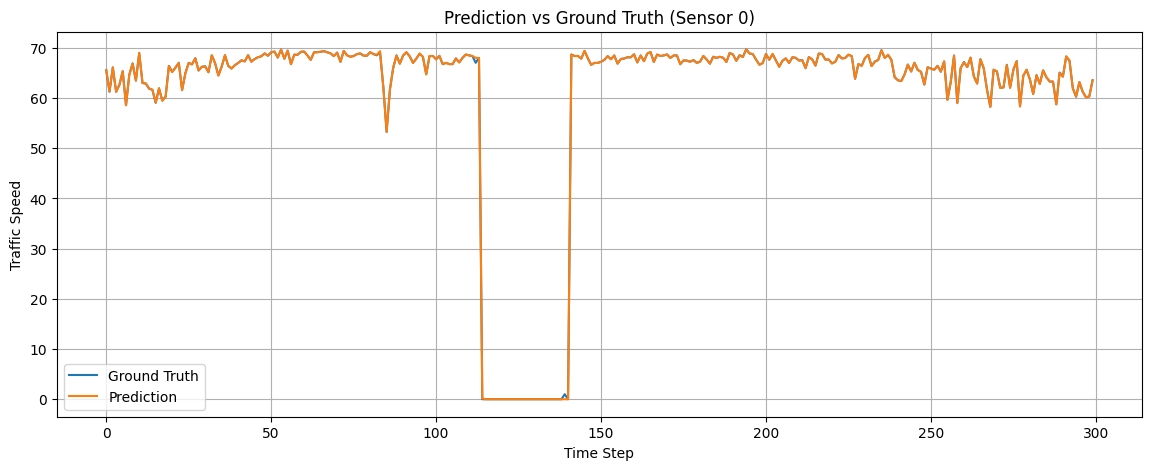

In [ ]:
print("\nTEST:")
test_steps = len(test_idx) // CONFIG['batch_size']
raw_data = np.load(loader.data_path)
model.evaluate(test_ds, steps=test_steps)
#return X, Y_delta, train_idx, val_idx, test_idx, stats
x_mean = stats['x_mean']
x_std  = stats['x_std']

y_mean = stats['y_mean']
y_std  = stats['y_std']

print("\n===== REAL TEST (NO LEAKAGE) =====")


# ============================================================
# Collect predictions
# ============================================================

preds = []
truth = []

for step, ((xs, xm, xl), y) in enumerate(test_ds):

    if step >= test_steps:
        break

    pred = model((xs, xm, xl), training=False)

    preds.append(pred.numpy())
    truth.append(y.numpy())

preds = np.concatenate(preds, axis=0)
truth = np.concatenate(truth, axis=0)

pred_delta = preds * y_std + y_mean
true_delta = truth * y_std + y_mean

num_samples = test_steps * CONFIG['batch_size']

valid_test_idx = test_idx[:num_samples]

prev_speed = raw_data[valid_test_idx - 1]
prev_speed = prev_speed[..., None]

# ============================================================
# Relative reconstruction
# ============================================================

pred_speed = prev_speed + pred_delta
true_speed = prev_speed + true_delta

# physical constraints
pred_speed = np.clip(pred_speed, 0, 70)
true_speed = np.clip(true_speed, 0, 70)

print(preds.shape)
print(y_mean.shape)
print(y_std.shape)

# ============================================================
# SAVE FINAL SPEEDS
# ============================================================

np.save("pred_speed.npy", pred_speed)
np.save("true_speed.npy", true_speed)
mae = mean_absolute_error(
    true_speed.reshape(-1),
    pred_speed.reshape(-1)
)

rmse = np.sqrt(mean_squared_error(
    true_speed.reshape(-1),
    pred_speed.reshape(-1)
))

mask = true_speed > 1

mape = np.mean(
    np.abs(
        (true_speed[mask] - pred_speed[mask]) /
        true_speed[mask]
    )
) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
# ============================================================
# Plot
# ============================================================

sensor_idx = 0

pred_series = pred_speed[:, sensor_idx, 0]
true_series = true_speed[:, sensor_idx, 0]

print("Pred min/max:", pred_series.min(), pred_series.max())
print("True min/max:", true_series.min(), true_series.max())

plt.figure(figsize=(14,5))

plt.plot(true_series[:300], label='Ground Truth')
plt.plot(pred_series[:300], label='Prediction')

plt.xlabel("Time Step")
plt.ylabel("Traffic Speed")

plt.title(f"Prediction vs Ground Truth (Sensor {sensor_idx})")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(preds.min(),preds.max())
print(truth.min(),truth.max())

-4.902663 4.946498
-5.0753126 5.0843177


In [ ]:
print("Pred delta min/max:",
      pred_delta.min(),
      pred_delta.max())

print("True delta min/max:",
      true_delta.min(),
      true_delta.max())

Pred delta min/max: -0.96601266 0.9728691
True delta min/max: -1.0 0.99999994
